# XGBoost Benchmark: Dataset Selection for xRFM vs XGBoost

**Course:** COMP9417 Machine Learning & Data Mining — Group Project 2026  
**Author:** Malcolm  

Datasets are loaded **directly from the zip files** in the `Kaggle Data/` folder.  
No downloads needed — just run all cells.

---

## How to use
1. Run all cells (`Cell → Run All`).
2. Results cache to `xgboost_benchmark_results.json` — re-running skips completed datasets.
3. Toggle `QUICK_HPO = True` to enable RandomizedSearchCV (~20 min extra).
4. Edit `proposed` in the last cell to test different shortlists before the group vote.

---

In [68]:
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for _pkg in ['xgboost', 'openpyxl', 'scipy']:
    try:
        __import__(_pkg)
    except ImportError:
        print(f'Installing {_pkg}...')
        _install(_pkg)

import os, json, time, zipfile, warnings
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
from sklearn.datasets import load_svmlight_file
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    StratifiedKFold, KFold, RandomizedSearchCV,
    cross_validate, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import roc_auc_score
from scipy.stats import loguniform, randint, uniform as sp_uniform
from xgboost import XGBClassifier, XGBRegressor

RANDOM_STATE   = 42
N_FOLDS        = 5
QUICK_HPO      = False
HPO_N_ITER     = 20
SUBSAMPLE_SEED = 42
RESULTS_JSON   = 'xgboost_benchmark_results.json'
KAGGLE_DATA_DIR = 'Kaggle Data'   # folder containing the downloaded zip files

sns.set_theme(style='whitegrid', font_scale=1.1)
print('Environment ready.')
print('Kaggle Data folder:', os.path.abspath(KAGGLE_DATA_DIR))
print('Zip files found:', [f for f in os.listdir(KAGGLE_DATA_DIR) if f.endswith('.zip')])

Environment ready.
Kaggle Data folder: /Users/malcolm/Library/CloudStorage/OneDrive-UNSW/UNSW Courses/COMP9417/Group Assignment/Kaggle Data
Zip files found: ['Bank Dataset.zip', 'Online News Dataset.zip', 'Gas Sensor Dataset.zip', 'RTiot Dataset.zip', 'Superconductivity Dataset.zip', 'Dry Bean Dataset.zip', 'Parkinsons-Telemonitoring-ucirvine.csv.zip']


---
## 1. Dataset Registry

| # | Dataset | Task | n | d | Zip file | Target col |
|---|---------|------|---|---|----------|------------|
| 1 | Bank Marketing | Classification | 45,211 | 16 | Bank Dataset.zip | `deposit` |
| 2 | Parkinson's Telemonitoring | Regression | 5,875 | 19 | Parkinsons-Telemonitoring-ucirvine.csv.zip | `total_updrs` |
| 3 | RT-IoT2022 | Classification | 123,117→30K | 83 | RTiot Dataset.zip | `Attack_type` |
| 4 | Online News Popularity | Regression | 39,797 | 58 | Online News Dataset.zip | `shares` |
| 5 | Superconductivity | Regression | 21,263 | 81 | Superconductivity Dataset.zip | `critical_temp` |
| 6 | Gas Sensor Array Drift | Classification | 13,910 | 128 | Gas Sensor Dataset.zip | libSVM batches |
| 7 | Dry Bean | Classification | 13,611 | 16 | Dry Bean Dataset.zip | `Class` |
| 8 | Taiwanese Bankruptcy | Classification | 6,819 | 95 | *(cached from prev run)* | — |
| 9 | Mice Protein Expression | Classification | 1,080 | 77 | *(not available)* | — |

In [69]:
@dataclass
class DatasetConfig:
    name: str
    task: str                   # 'classification' or 'regression'
    n_samples: int
    n_features: int
    feature_types: str          # 'numerical' or 'mixed'
    target_col: str             # Column name for the target variable
    local_zip: Optional[str]    # Zip filename inside KAGGLE_DATA_DIR. None = skip.
    subsample_n: Optional[int]  # Stratified subsample to N rows (None = use all)
    log_transform_target: bool  # Apply np.log1p to target
    notes: str
    zip_file: Optional[str] = None  # Specific file inside zip (None = auto-detect)
    drop_cols: List[str] = field(default_factory=list)
    n_classes: Optional[int] = field(default=None, repr=False)


DATASET_REGISTRY: List[DatasetConfig] = [
    DatasetConfig(
        name='Bank Marketing', task='classification',
        n_samples=45211, n_features=16, feature_types='mixed',
        target_col='deposit',
        local_zip='Bank Dataset.zip', zip_file='bank.csv',
        subsample_n=None, log_transform_target=False,
        notes='Binary (yes/no). Mixed numeric/categorical. ~88% no.',
    ),
    DatasetConfig(
        name="Parkinson's Telemonitoring", task='regression',
        n_samples=5875, n_features=19, feature_types='numerical',
        target_col='total_updrs',
        local_zip='Parkinsons-Telemonitoring-ucirvine.csv.zip',
        zip_file='Parkinsons-Telemonitoring-ucirvine.csv',
        drop_cols=['motor_updrs', 'subject'],
        subsample_n=None, log_transform_target=False,
        notes='Predict total_updrs. motor_updrs + subject dropped.',
    ),
    DatasetConfig(
        name='RT-IoT2022', task='classification',
        n_samples=123117, n_features=83, feature_types='mixed',
        target_col='Attack_type',
        local_zip='RTiot Dataset.zip', zip_file='RT_IOT2022.csv',
        drop_cols=['no'],
        subsample_n=30000, log_transform_target=False,
        notes='Multi-class IDS. Stratified subsample to 30K for speed.',
    ),
    DatasetConfig(
        name='Online News Popularity', task='regression',
        n_samples=39797, n_features=58, feature_types='mixed',
        target_col='shares',
        local_zip='Online News Dataset.zip', zip_file='OnlineNewsPopularity.csv',
        drop_cols=['url'],
        subsample_n=None, log_transform_target=True,
        notes='Predict log1p(shares). Heavy-tailed target log-transformed.',
    ),
    DatasetConfig(
        name='Superconductivity', task='regression',
        n_samples=21263, n_features=81, feature_types='numerical',
        target_col='critical_temp',
        local_zip='Superconductivity Dataset.zip', zip_file='train.csv',
        subsample_n=None, log_transform_target=False,
        notes='Predict critical temperature.',
    ),
    DatasetConfig(
        name='Gas Sensor Array Drift', task='classification',
        n_samples=13910, n_features=128, feature_types='numerical',
        target_col='gas_type',
        local_zip='Gas Sensor Dataset.zip', zip_file=None,  # multi-batch libSVM
        subsample_n=None, log_transform_target=False,
        notes='6-class gas type. libSVM format, 10 batches concatenated.',
    ),
    DatasetConfig(
        name='Dry Bean', task='classification',
        n_samples=13611, n_features=16, feature_types='numerical',
        target_col='Class',
        local_zip='Dry Bean Dataset.zip', zip_file='Dry_Bean_Dataset.xlsx',
        subsample_n=None, log_transform_target=False,
        notes='7-class bean type classification.',
    ),
    DatasetConfig(
        name='Taiwanese Bankruptcy', task='classification',
        n_samples=6819, n_features=95, feature_types='numerical',
        target_col='Bankrupt?',
        local_zip=None,  # cached from previous run
        subsample_n=None, log_transform_target=False,
        notes='Binary; ~97% non-bankrupt. Result cached from previous run.',
    ),
    DatasetConfig(
        name='Mice Protein Expression', task='classification',
        n_samples=1080, n_features=77, feature_types='numerical',
        target_col='class',
        local_zip=None,  # zip not in Kaggle Data folder
        subsample_n=None, log_transform_target=False,
        notes='SKIPPED -- zip not present in Kaggle Data folder.',
    ),
]

print(f'Registry: {len(DATASET_REGISTRY)} datasets')
print(f'{"Dataset":<35} {"Task":<14} {"n":>8}  {"d":>3}  Zip')
print('-' * 90)
for c in DATASET_REGISTRY:
    z = c.local_zip or '(skipped)'
    print(f'{c.name:<35} {c.task:<14} {c.n_samples:>8,}  {c.n_features:>3}  {z}')

Registry: 9 datasets
Dataset                             Task                  n    d  Zip
------------------------------------------------------------------------------------------
Bank Marketing                      classification   45,211   16  Bank Dataset.zip
Parkinson's Telemonitoring          regression        5,875   19  Parkinsons-Telemonitoring-ucirvine.csv.zip
RT-IoT2022                          classification  123,117   83  RTiot Dataset.zip
Online News Popularity              regression       39,797   58  Online News Dataset.zip
Superconductivity                   regression       21,263   81  Superconductivity Dataset.zip
Gas Sensor Array Drift              classification   13,910  128  Gas Sensor Dataset.zip
Dry Bean                            classification   13,611   16  Dry Bean Dataset.zip
Taiwanese Bankruptcy                classification    6,819   95  (skipped)
Mice Protein Expression             classification    1,080   77  (skipped)


---
## 2. Data Loading

Datasets are read **directly from the zip files** in `Kaggle Data/` — no extraction needed.

- **Gas Sensor** batches are in libSVM sparse format (`label feat:val ...`), parsed with `load_svmlight_file`.
- **Dry Bean** is an Excel file (`.xlsx`) read via `openpyxl`.
- All other datasets are plain CSV.

**SKIP** = `local_zip=None` (dataset not in folder, or result already cached).

Run `probe_datasets()` to confirm all zips open correctly before the full benchmark.

In [70]:
# ── Gas Sensor special loader (libSVM multi-batch) ───────────────────────────

def _load_gas_sensor(zip_path: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Load and concatenate all batch*.dat files from the Gas Sensor zip.
    Format: libSVM sparse  ->  label feat1:val feat2:val ... feat128:val
    Labels 1-6 correspond to gas types (Ethanol, Ethylene, Ammonia, etc.).
    """
    all_X, all_y = [], []
    with zipfile.ZipFile(zip_path) as z:
        batch_files = sorted(n for n in z.namelist() if n.endswith('.dat'))
        for bfile in batch_files:
            with z.open(bfile) as f:
                X_batch, y_batch = load_svmlight_file(f, n_features=128)
                all_X.append(X_batch)
                all_y.append(y_batch)

    X_dense = scipy.sparse.vstack(all_X).toarray()
    y_all   = np.concatenate(all_y).astype(int)

    feat_names = [f'sensor_{i+1:03d}' for i in range(128)]
    return pd.DataFrame(X_dense, columns=feat_names), pd.Series(y_all, name='gas_type')


# ── Main loader ───────────────────────────────────────────────────────────────

def load_dataset(cfg: DatasetConfig) -> Tuple[pd.DataFrame, pd.Series, DatasetConfig]:
    """
    Load dataset from a local zip file in KAGGLE_DATA_DIR.
    Raises FileNotFoundError when local_zip=None (shown as SKIP in probe).
    """
    if cfg.local_zip is None:
        raise FileNotFoundError(
            f'{cfg.name!r} has no local_zip configured (not in Kaggle Data folder).'
        )

    zip_path = os.path.join(KAGGLE_DATA_DIR, cfg.local_zip)
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f'Zip not found: {zip_path}')

    # -- Gas Sensor: special multi-batch libSVM loader
    if cfg.name == 'Gas Sensor Array Drift':
        X, y = _load_gas_sensor(zip_path)

    else:
        # -- Normal CSV / XLSX inside zip
        with zipfile.ZipFile(zip_path) as z:
            # Use specified file or auto-pick largest CSV/XLSX
            if cfg.zip_file:
                fname = cfg.zip_file
            else:
                candidates = [n for n in z.namelist()
                              if n.endswith(('.csv','.xlsx','.xls'))
                              and not n.startswith('__MACOSX')]
                fname = max(candidates, key=lambda n: z.getinfo(n).file_size)

            with z.open(fname) as f:
                if fname.endswith(('.xlsx', '.xls')):
                    df = pd.read_excel(BytesIO(f.read()))
                else:
                    df = pd.read_csv(f)

        # Strip whitespace from column names
        df.columns = df.columns.str.strip()

        if cfg.target_col not in df.columns:
            raise RuntimeError(
                f'Target {cfg.target_col!r} not in {cfg.name}. '
                f'Columns: {list(df.columns)[:10]}'
            )

        y = df[cfg.target_col].copy()
        X = df.drop(columns=[cfg.target_col] + cfg.drop_cols, errors='ignore')
        X = X.reset_index(drop=True)
        y = pd.Series(y.values, name=cfg.target_col)

    # -- Stratified subsample for speed
    if cfg.subsample_n is not None and len(X) > cfg.subsample_n:
        strat = y if cfg.task == 'classification' else None
        X, _, y, _ = train_test_split(
            X, y, train_size=cfg.subsample_n,
            random_state=SUBSAMPLE_SEED, stratify=strat,
        )
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)

    # -- Log-transform regression target
    if cfg.log_transform_target:
        y = pd.Series(np.log1p(y.astype(float)), name=y.name)

    # -- Label-encode all classification targets (handles strings AND non-zero-based ints e.g. Gas Sensor 1-6 -> 0-5)
    if cfg.task == 'classification':
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y), name=y.name)

    if cfg.task == 'regression':
        y = y.astype(float)

    if cfg.task == 'classification':
        cfg.n_classes = int(y.nunique())

    return X, y, cfg

In [71]:
def probe_datasets(registry: List[DatasetConfig]) -> None:
    """Quick load check. SKIP = no local_zip. FAIL = file/parse error."""
    print(f'{"Dataset":<35} {"Status":<8} {"X shape":<16} {"y dtype":<12} n_classes')
    print('-' * 88)
    for cfg in registry:
        try:
            X, y, cfg = load_dataset(cfg)
            nc = str(cfg.n_classes) if cfg.task == 'classification' else 'N/A'
            print(f'{cfg.name:<35} OK       {str(X.shape):<16} {str(y.dtype):<12} {nc}')
        except FileNotFoundError:
            print(f'{cfg.name:<35} SKIP     (no local_zip)')
        except Exception as e:
            print(f'{cfg.name:<35} FAIL     {type(e).__name__}: {str(e)[:60]}')


probe_datasets(DATASET_REGISTRY)

Dataset                             Status   X shape          y dtype      n_classes
----------------------------------------------------------------------------------------
Bank Marketing                      OK       (11162, 16)      int64        2
Parkinson's Telemonitoring          OK       (5875, 19)       float64      N/A
RT-IoT2022                          OK       (30000, 83)      int64        12
Online News Popularity              OK       (39644, 59)      float64      N/A
Superconductivity                   OK       (21263, 81)      float64      N/A
Gas Sensor Array Drift              OK       (13910, 128)     int64        6
Dry Bean                            OK       (13611, 16)      int64        7
Taiwanese Bankruptcy                SKIP     (no local_zip)
Mice Protein Expression             SKIP     (no local_zip)


---
## 3. Preprocessing Pipeline

A `ColumnTransformer` handles mixed feature types:
- **Numeric:** median imputation only — XGBoost is scale-invariant.
- **Categorical:** mode imputation + `OrdinalEncoder`.

The preprocessor is built per-dataset and injected via `pipe.set_params(pre=build_preprocessor(X))`.

In [72]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
    transformers = []
    if num_cols:
        transformers.append(('num', SimpleImputer(strategy='median'), num_cols))
    if cat_cols:
        transformers.append(('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), cat_cols))
    return ColumnTransformer(transformers=transformers, remainder='drop')


def build_pipeline(cfg: DatasetConfig) -> Pipeline:
    n_cls = cfg.n_classes or 2
    p = dict(n_estimators=300, max_depth=6, learning_rate=0.05,
             subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
             random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    if cfg.task == 'classification':
        p['objective']   = 'multi:softprob' if n_cls > 2 else 'binary:logistic'
        p['eval_metric'] = 'mlogloss'       if n_cls > 2 else 'logloss'
        model = XGBClassifier(**p)
    else:
        p['objective'] = 'reg:squarederror'; p['eval_metric'] = 'rmse'
        model = XGBRegressor(**p)
    return Pipeline([('pre', 'passthrough'), ('xgb', model)])


HPO_PARAM_GRID = {
    'xgb__n_estimators':     randint(100, 600),
    'xgb__max_depth':        randint(3, 10),
    'xgb__learning_rate':    loguniform(1e-2, 3e-1),
    'xgb__subsample':        sp_uniform(0.5, 0.5),
    'xgb__colsample_bytree': sp_uniform(0.5, 0.5),
    'xgb__min_child_weight': randint(1, 10),
}
print('Pipeline builders defined.')

Pipeline builders defined.


---
## 4. Benchmark Engine

Runs 5-fold CV (`StratifiedKFold` for classification, `KFold` for regression).

**Metrics:** Accuracy + macro-F1 + ROC-AUC (classification) | RMSE + MAE + R² (regression).

Note: `n_jobs=1` in `cross_validate` avoids a macOS fork conflict with XGBoost's OpenMP.

In [73]:
def compute_cv_metrics(
    cfg, cv_results, X, y, estimators, cv_splitter,
) -> dict:
    m = {'dataset': cfg.name, 'task': cfg.task,
         'n_samples': len(X), 'n_features': X.shape[1]}

    if cfg.task == 'classification':
        m['accuracy_mean'] = float(np.mean(cv_results['test_accuracy']))
        m['accuracy_std']  = float(np.std( cv_results['test_accuracy']))
        m['f1_macro_mean'] = float(np.mean(cv_results['test_f1_macro']))
        m['f1_macro_std']  = float(np.std( cv_results['test_f1_macro']))

        auc_scores = []
        y_arr  = np.array(y)
        splits = list(cv_splitter.split(X, y_arr))
        for est, (_, vi) in zip(estimators, splits):
            try:
                pr = est.predict_proba(X.iloc[vi])
                yv = y_arr[vi]
                auc = (roc_auc_score(yv, pr[:,1]) if cfg.n_classes == 2
                       else roc_auc_score(yv, pr, multi_class='ovr', average='macro'))
                auc_scores.append(auc)
            except Exception:
                pass
        m['roc_auc_mean'] = float(np.mean(auc_scores)) if auc_scores else float('nan')
        m['roc_auc_std']  = float(np.std(auc_scores))  if auc_scores else float('nan')
        for k in ['rmse_mean','rmse_std','mae_mean','mae_std','r2_mean','r2_std']:
            m[k] = float('nan')

    else:
        m['rmse_mean'] = float(-np.mean(cv_results['test_neg_root_mean_squared_error']))
        m['rmse_std']  = float( np.std( cv_results['test_neg_root_mean_squared_error']))
        m['mae_mean']  = float(-np.mean(cv_results['test_neg_mean_absolute_error']))
        m['mae_std']   = float( np.std( cv_results['test_neg_mean_absolute_error']))
        m['r2_mean']   = float( np.mean(cv_results['test_r2']))
        m['r2_std']    = float( np.std( cv_results['test_r2']))
        for k in ['accuracy_mean','accuracy_std','f1_macro_mean','f1_macro_std',
                  'roc_auc_mean','roc_auc_std']:
            m[k] = float('nan')

    m['fit_time_s'] = float(np.sum(cv_results['fit_time']))
    return m

In [74]:
def run_benchmark(
    registry: List[DatasetConfig],
    quick_hpo: bool = False,
) -> Tuple[pd.DataFrame, Dict]:
    all_results:  List[dict] = []
    raw_cv_store: Dict       = {}

    cached = {}
    if os.path.exists(RESULTS_JSON):
        with open(RESULTS_JSON) as f:
            try:
                cached = {r['dataset']: r for r in json.load(f)}
                print(f'Loaded {len(cached)} cached result(s) from {RESULTS_JSON}')
            except Exception:
                pass

    for cfg in registry:
        sep = '=' * 65
        print(); print(sep)
        print(f'  {cfg.name}  ({cfg.task})')
        print(sep)

        if cfg.name in cached:
            print('  [CACHED] Skipping re-fit.')
            all_results.append(cached[cfg.name])
            continue

        try:
            X, y, cfg = load_dataset(cfg)
            print(f'  Loaded: X={X.shape}, y={y.shape}')
        except FileNotFoundError:
            print('  [SKIP] No local_zip configured.')
            continue
        except Exception as e:
            print(f'  [ERROR] {type(e).__name__}: {str(e)[:120]}')
            continue

        pipe = build_pipeline(cfg)
        pipe.set_params(pre=build_preprocessor(X))

        if cfg.task == 'classification':
            cv_splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                                          random_state=RANDOM_STATE)
            scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}
        else:
            cv_splitter = KFold(n_splits=N_FOLDS, shuffle=True,
                                random_state=RANDOM_STATE)
            scoring = {
                'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
                'neg_mean_absolute_error':     'neg_mean_absolute_error',
                'r2':                          'r2',
            }

        if quick_hpo:
            inner_cv = (StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)
                        if cfg.task == 'classification'
                        else KFold(3, shuffle=True, random_state=RANDOM_STATE))
            primary = 'accuracy' if cfg.task == 'classification' else 'r2'
            pipe = RandomizedSearchCV(pipe, HPO_PARAM_GRID, n_iter=HPO_N_ITER,
                                      scoring=primary, cv=inner_cv,
                                      random_state=RANDOM_STATE, n_jobs=1, refit=True)

        t0 = time.time()
        try:
            cv_results = cross_validate(
                pipe, X, y, cv=cv_splitter, scoring=scoring,
                return_estimator=True, n_jobs=1, error_score='raise',
            )
        except Exception as e:
            print(f'  [ERROR] CV failed: {type(e).__name__}: {str(e)[:120]}')
            continue

        elapsed = time.time() - t0
        print(f'  CV complete in {elapsed:.1f}s')

        row = compute_cv_metrics(cfg, cv_results, X, y,
                                 cv_results['estimator'], cv_splitter)
        row['total_time_s'] = elapsed
        all_results.append(row)
        raw_cv_store[cfg.name] = {
            'cv_results': cv_results, 'X': X, 'y': y,
            'cfg': cfg, 'cv_splitter': cv_splitter,
        }

        with open(RESULTS_JSON, 'w') as f:
            json.dump(all_results, f, indent=2, default=str)
        print(f'  Cached to {RESULTS_JSON}')

    return pd.DataFrame(all_results), raw_cv_store

---
## 5. Run Benchmark

Expected runtimes (no HPO, 5-fold CV):

| Dataset | Est. time |
|---------|----------|
| Energy Efficiency / Parkinson's / Taiwanese Bankruptcy / Dry Bean | < 1 min |
| Bank Marketing / Gas Sensor / Mice Protein / Superconductivity | 2–5 min |
| Online News / RT-IoT2022 (30K) | 5–15 min |

Re-running skips datasets already cached in `xgboost_benchmark_results.json`.

In [75]:
results_df, raw_cv_store = run_benchmark(DATASET_REGISTRY, quick_hpo=QUICK_HPO)

print()
print('Done. Datasets completed:', len(results_df))
print(results_df[['dataset','task','n_samples','n_features']].to_string(index=False))

Loaded 3 cached result(s) from xgboost_benchmark_results.json

  Bank Marketing  (classification)
  Loaded: X=(11162, 16), y=(11162,)
  CV complete in 2.0s
  Cached to xgboost_benchmark_results.json

  Parkinson's Telemonitoring  (regression)
  [CACHED] Skipping re-fit.

  RT-IoT2022  (classification)
  Loaded: X=(30000, 83), y=(30000,)
  CV complete in 17.5s
  Cached to xgboost_benchmark_results.json

  Online News Popularity  (regression)
  [CACHED] Skipping re-fit.

  Superconductivity  (regression)
  [CACHED] Skipping re-fit.

  Gas Sensor Array Drift  (classification)
  Loaded: X=(13910, 128), y=(13910,)
  CV complete in 19.6s
  Cached to xgboost_benchmark_results.json

  Dry Bean  (classification)
  Loaded: X=(13611, 16), y=(13611,)
  CV complete in 11.6s
  Cached to xgboost_benchmark_results.json

  Taiwanese Bankruptcy  (classification)
  [SKIP] No local_zip configured.

  Mice Protein Expression  (classification)
  [SKIP] No local_zip configured.

Done. Datasets completed: 7
 

---
## 6. Results Analysis

1. **Summary table** — mean±std per metric
2. **Classification bar charts** — Accuracy, F1-macro, ROC-AUC
3. **Regression bar charts** — RMSE, MAE, R²
4. **Normalised heatmap** — all datasets on a unified 0–1 scale
5. **Feature importance plots** — top-15 features per dataset
6. **Runtime table**

In [76]:
def format_results_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in df.iterrows():
        row = {'Dataset': r['dataset'], 'Task': r['task'],
               'n': int(r['n_samples']), 'd': int(r['n_features'])}
        if r['task'] == 'classification':
            row['Accuracy'] = '{:.3f}±{:.3f}'.format(r['accuracy_mean'], r['accuracy_std'])
            row['F1-macro'] = '{:.3f}±{:.3f}'.format(r['f1_macro_mean'], r['f1_macro_std'])
            row['ROC-AUC']  = '{:.3f}±{:.3f}'.format(r['roc_auc_mean'],  r['roc_auc_std'])
            row['RMSE'] = row['MAE'] = row['R2'] = '—'
        else:
            row['Accuracy'] = row['F1-macro'] = row['ROC-AUC'] = '—'
            row['RMSE'] = '{:.4f}±{:.4f}'.format(r['rmse_mean'], r['rmse_std'])
            row['MAE']  = '{:.4f}±{:.4f}'.format(r['mae_mean'],  r['mae_std'])
            row['R2']   = '{:.3f}±{:.3f}'.format( r['r2_mean'],  r['r2_std'])
        row['Time(s)'] = '{:.0f}'.format(r.get('total_time_s', 0))
        rows.append(row)
    return pd.DataFrame(rows)


if not results_df.empty:
    print(format_results_table(results_df).to_string(index=False))
else:
    print('No results yet.')

                   Dataset           Task     n   d    Accuracy    F1-macro     ROC-AUC          RMSE           MAE          R2 Time(s)
            Bank Marketing classification 11162  16 0.859±0.004 0.859±0.004 0.927±0.003             —             —           —       2
Parkinson's Telemonitoring     regression  5875  19           —           —           — 2.7338±0.1303 1.8023±0.0608 0.934±0.007       2
                RT-IoT2022 classification 30000  83 0.997±0.001 0.870±0.037 0.998±0.003             —             —           —      17
    Online News Popularity     regression 39644  59           —           —           — 0.8398±0.0092 0.6185±0.0034 0.184±0.008       4
         Superconductivity     regression 21263  81           —           —           — 9.6867±0.2469 5.9293±0.1097 0.920±0.003       4
    Gas Sensor Array Drift classification 13910 128 0.994±0.001 0.993±0.001 1.000±0.000             —             —           —      20
                  Dry Bean classification 13611 

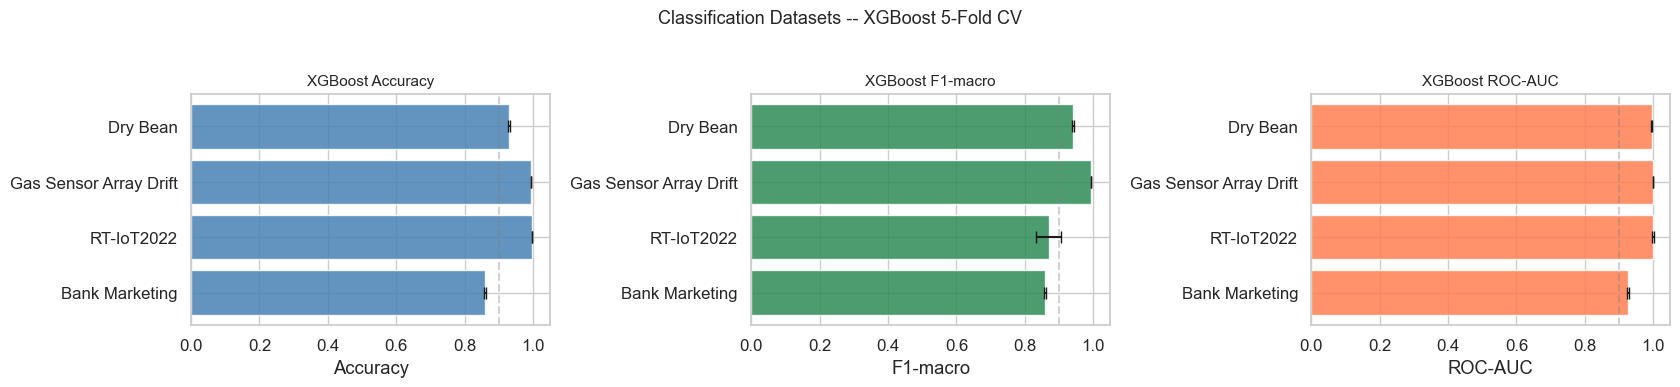

In [77]:
def plot_classification_metrics(df: pd.DataFrame) -> None:
    clf_df = df[df['task'] == 'classification'].copy()
    if clf_df.empty: print('No classification results.'); return
    names = clf_df['dataset'].tolist()
    h = max(3.5, len(names) * 0.7 + 1)
    fig, axes = plt.subplots(1, 3, figsize=(17, h))
    for ax, (m, s, label, color) in zip(axes, [
        ('accuracy_mean','accuracy_std','Accuracy','steelblue'),
        ('f1_macro_mean','f1_macro_std','F1-macro','seagreen'),
        ('roc_auc_mean', 'roc_auc_std', 'ROC-AUC', 'coral'),
    ]):
        ax.barh(names, clf_df[m], xerr=clf_df[s], color=color, alpha=0.85,
                capsize=4, error_kw={'linewidth':1.5})
        ax.set_xlabel(label); ax.set_xlim(0, 1.05)
        ax.axvline(0.9, color='gray', linestyle='--', alpha=0.35)
        ax.set_title(f'XGBoost {label}', fontsize=11)
    fig.suptitle('Classification Datasets -- XGBoost 5-Fold CV', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('xgb_classification_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_classification_metrics(results_df)

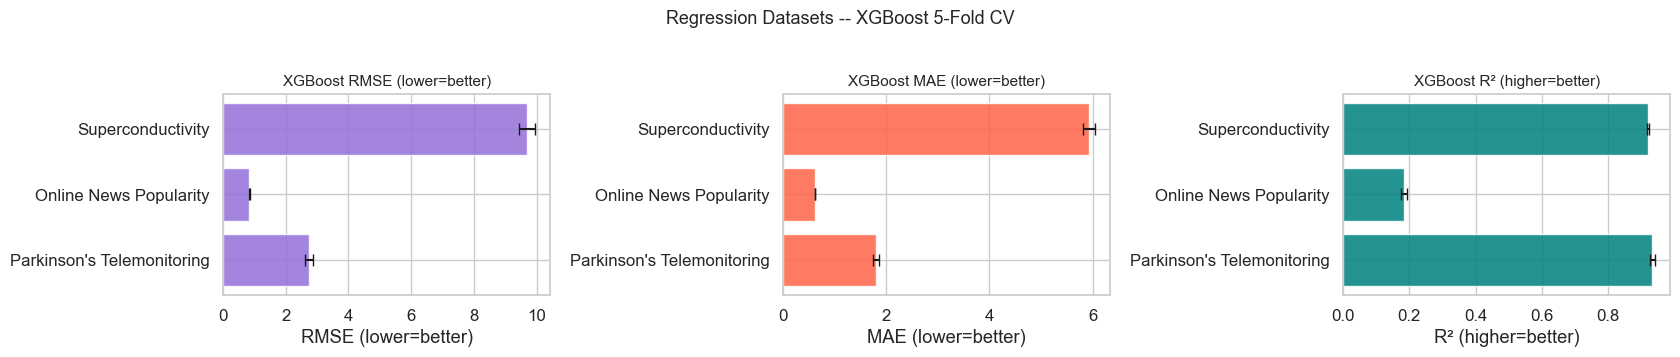

In [78]:
def plot_regression_metrics(df: pd.DataFrame) -> None:
    reg_df = df[df['task'] == 'regression'].copy()
    if reg_df.empty: print('No regression results.'); return
    names = reg_df['dataset'].tolist()
    h = max(3.5, len(names) * 0.7 + 1)
    fig, axes = plt.subplots(1, 3, figsize=(17, h))
    for ax, (m, s, label, color) in zip(axes, [
        ('rmse_mean','rmse_std','RMSE (lower=better)','mediumpurple'),
        ('mae_mean', 'mae_std', 'MAE (lower=better)', 'tomato'),
        ('r2_mean',  'r2_std',  'R² (higher=better)',  'teal'),
    ]):
        ax.barh(names, reg_df[m], xerr=reg_df[s], color=color, alpha=0.85,
                capsize=4, error_kw={'linewidth':1.5})
        ax.set_xlabel(label); ax.set_title(f'XGBoost {label}', fontsize=11)
    fig.suptitle('Regression Datasets -- XGBoost 5-Fold CV', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('xgb_regression_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_regression_metrics(results_df)

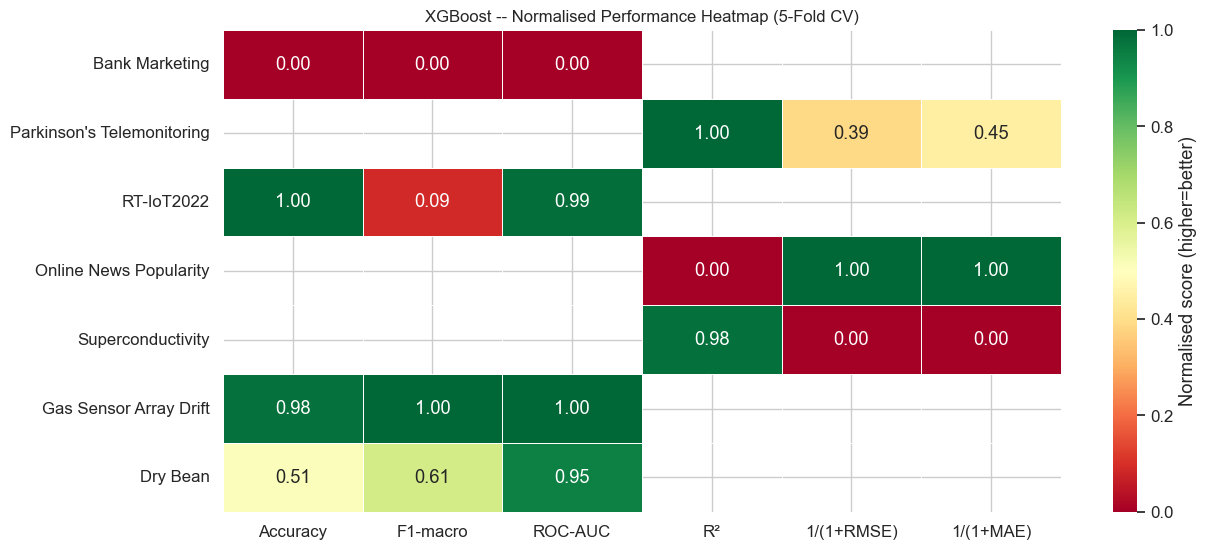

In [79]:
def plot_metrics_heatmap(df: pd.DataFrame) -> None:
    if df.empty: print('No results yet.'); return
    metric_cols = ['accuracy_mean','f1_macro_mean','roc_auc_mean',
                   'r2_mean','rmse_mean','mae_mean']
    col_labels  = ['Accuracy','F1-macro','ROC-AUC','R²','1/(1+RMSE)','1/(1+MAE)']
    hmap = df[['dataset']+metric_cols].set_index('dataset').copy().astype(float)
    for col in ['rmse_mean','mae_mean']:
        hmap[col] = 1.0 / (1.0 + hmap[col])
    for col in metric_cols:
        mn, mx = hmap[col].min(), hmap[col].max()
        if mx > mn: hmap[col] = (hmap[col] - mn) / (mx - mn)
    hmap.columns = col_labels
    fig, ax = plt.subplots(figsize=(13, max(4, len(df)*0.6+1.5)))
    sns.heatmap(hmap, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5, ax=ax,
                cbar_kws={'label':'Normalised score (higher=better)'})
    ax.set_title('XGBoost -- Normalised Performance Heatmap (5-Fold CV)', fontsize=12)
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('xgb_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_metrics_heatmap(results_df)

In [80]:
def plot_feature_importances(cfg, cv_results, X, top_n=15):
    est      = cv_results['estimator'][0]
    xgb_step = est.named_steps['xgb']
    pre_step = est.named_steps['pre']
    feat_names = []
    if hasattr(pre_step, 'transformers_'):
        for _, tr, cols in pre_step.transformers_:
            feat_names.extend(
                tr.get_feature_names_out(cols).tolist()
                if hasattr(tr, 'get_feature_names_out') else list(cols)
            )
    else:
        feat_names = list(X.columns)
    importances = xgb_step.feature_importances_
    n   = min(top_n, len(importances))
    idx = np.argsort(importances)[-n:]
    labels = [feat_names[i] if i < len(feat_names) else f'f{i}' for i in idx]
    fig, ax = plt.subplots(figsize=(9, max(4, n*0.38)))
    ax.barh(labels, importances[idx], color='steelblue', alpha=0.85)
    ax.set_title(f'Top-{n} Feature Importances: {cfg.name}', fontsize=11)
    ax.set_xlabel('XGBoost gain importance')
    plt.tight_layout()
    safe = cfg.name.replace(' ','_').replace("'",'').replace('/','_')
    plt.savefig(f'xgb_importance_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

Feature importances: Bank Marketing


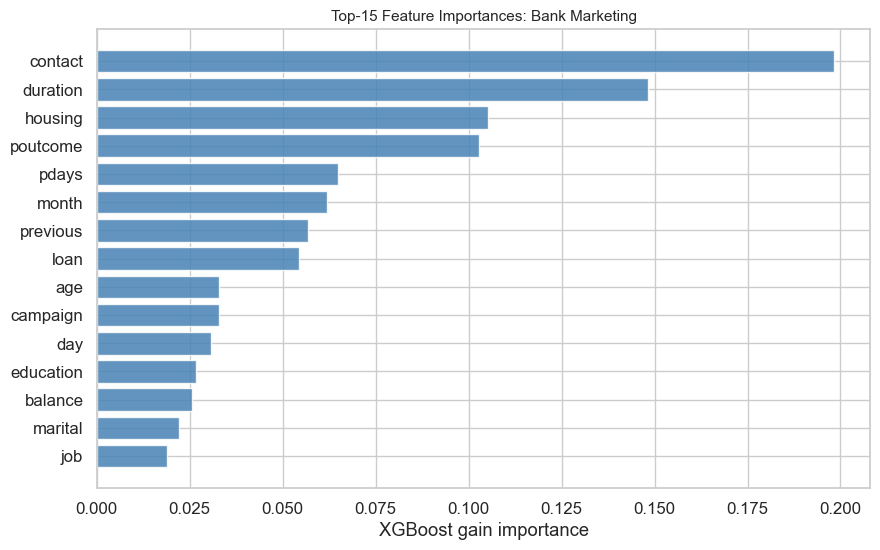

Feature importances: RT-IoT2022


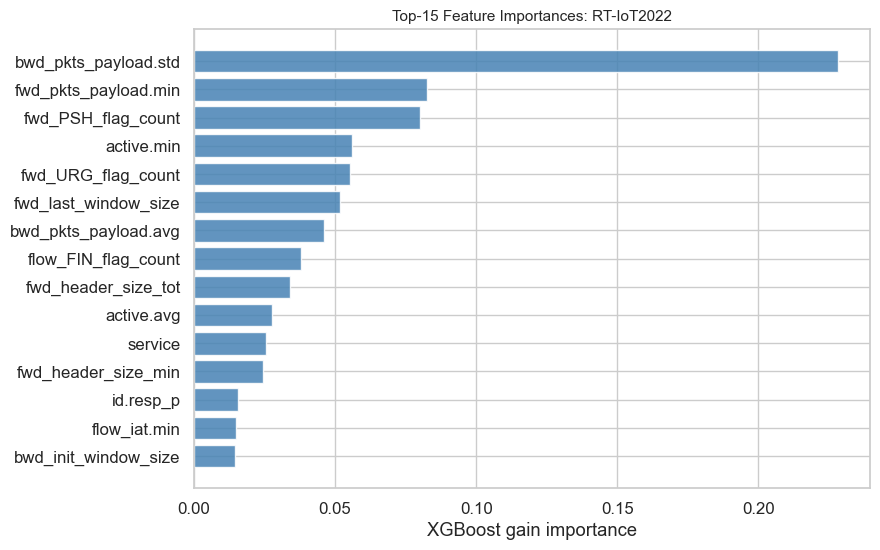

Feature importances: Gas Sensor Array Drift


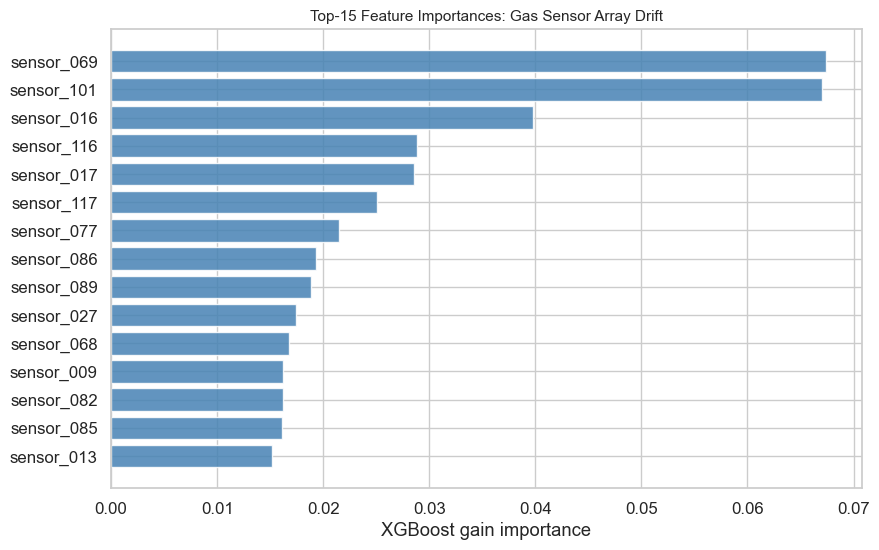

Feature importances: Dry Bean


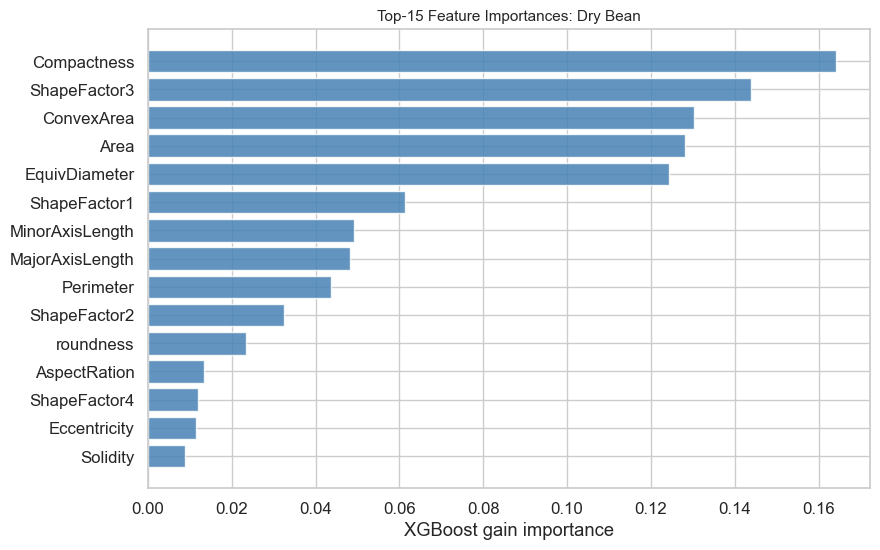

In [81]:
if raw_cv_store:
    for ds_name, store in raw_cv_store.items():
        print(f'Feature importances: {ds_name}')
        try:
            plot_feature_importances(store['cfg'], store['cv_results'], store['X'])
        except Exception as e:
            print(f'  [SKIP] {type(e).__name__}: {e}')
else:
    print('No raw CV results (clear cache to regenerate).')

In [82]:
if not results_df.empty and 'total_time_s' in results_df.columns:
    rt = results_df[['dataset','task','n_samples','n_features','total_time_s']].copy()
    rt['time_per_fold_s'] = (rt['total_time_s'] / N_FOLDS).round(1)
    rt['total_time_s']    = rt['total_time_s'].round(1)
    print(rt.sort_values('total_time_s', ascending=False).to_string(index=False))
else:
    print('No timing data available.')

                   dataset           task  n_samples  n_features  total_time_s  time_per_fold_s
    Gas Sensor Array Drift classification      13910         128          19.6              3.9
                RT-IoT2022 classification      30000          83          17.5              3.5
                  Dry Bean classification      13611          16          11.6              2.3
         Superconductivity     regression      21263          81           4.3              0.9
    Online News Popularity     regression      39644          59           4.2              0.8
Parkinson's Telemonitoring     regression       5875          19           2.2              0.4
            Bank Marketing classification      11162          16           2.0              0.4


---
## 7. Dataset Portfolio Checklist

Edit `proposed` to try different shortlists before the group vote.

**Requirements:** ≥2 classification | ≥2 regression | ≥5 total | n>10K | d>50 | mixed features

In [83]:
REQUIREMENTS = {
    'At least 2 classification tasks':    lambda s: sum(1 for c in s if c.task=='classification') >= 2,
    'At least 2 regression tasks':        lambda s: sum(1 for c in s if c.task=='regression') >= 2,
    'At least 5 tabular datasets':        lambda s: len(s) >= 5,
    'At least 1 dataset with n > 10,000': lambda s: any(c.n_samples > 10_000 for c in s),
    'At least 1 dataset with d > 50':     lambda s: any(c.n_features > 50 for c in s),
    'At least 1 mixed feature types':     lambda s: any(c.feature_types == 'mixed' for c in s),
}


def check_portfolio(selected_names, registry, results):
    sel = [c for c in registry if c.name in selected_names]
    sep = '=' * 60
    print(sep); print('  PORTFOLIO REQUIREMENT CHECK'); print(sep)
    ok = True
    for req, fn in REQUIREMENTS.items():
        passed = fn(sel); ok = ok and passed
        print(f'  [{"PASS" if passed else "FAIL"}]  {req}')
    print('-' * 60)
    print('  ALL REQUIREMENTS SATISFIED' if ok
          else '  WARNING: One or more requirements NOT satisfied')
    print()
    print(f'  {"Name":<35} {"Task":<14} {"n":>8}  {"d":>3}  Tags')
    print('  ' + '-' * 70)
    for c in sel:
        tags = (['n>10K'] if c.n_samples>10000 else []) + \
               (['d>50']  if c.n_features>50   else []) + \
               (['mixed'] if c.feature_types=='mixed' else [])
        print(f'  {c.name:<35} {c.task:<14} {c.n_samples:>8,}  {c.n_features:>3}  {tags}')
    if not results.empty:
        sr = results[results['dataset'].isin(selected_names)]
        if not sr.empty:
            print(); print('Metric summary:')
            print(format_results_table(sr).to_string(index=False))


# -- Edit this list before the group vote --------------------------------
proposed = [
    'Bank Marketing',            # classification, mixed, n=45K
    'RT-IoT2022',                # classification, mixed, n=123K (30K subsample), d=83
    'Gas Sensor Array Drift',    # classification, n=13.9K, d=128
    'Online News Popularity',    # regression, mixed, n=40K, d=58
    'Superconductivity',         # regression, n=21K, d=81
    "Parkinson's Telemonitoring", # regression, n=5.9K
]

check_portfolio(proposed, DATASET_REGISTRY, results_df)

  PORTFOLIO REQUIREMENT CHECK
  [PASS]  At least 2 classification tasks
  [PASS]  At least 2 regression tasks
  [PASS]  At least 5 tabular datasets
  [PASS]  At least 1 dataset with n > 10,000
  [PASS]  At least 1 dataset with d > 50
  [PASS]  At least 1 mixed feature types
------------------------------------------------------------
  ALL REQUIREMENTS SATISFIED

  Name                                Task                  n    d  Tags
  ----------------------------------------------------------------------
  Bank Marketing                      classification   45,211   16  ['n>10K', 'mixed']
  Parkinson's Telemonitoring          regression        5,875   19  []
  RT-IoT2022                          classification  123,117   83  ['n>10K', 'd>50', 'mixed']
  Online News Popularity              regression       39,797   58  ['n>10K', 'd>50', 'mixed']
  Superconductivity                   regression       21,263   81  ['n>10K', 'd>50']
  Gas Sensor Array Drift              classification  